# Module: Clustering Stability

When analyzing (spatial) transcriptomics data, cells are typically clustered
into cell types based on their RNA expression. If the segmentation of a spatial transcriptomics
dataset went well, we would assume that this clustering is somewhat stable,
even if we only cluster on parts of the data. The `clustering stability` (`cs`)
module includes some functions to apply clustering and assess its robustness.
The figure below shows a bad clustering (lots of overlap) vs. a good clustering.

<center>
 <img src='../_static/img/docs/clustering_stability.png' width='90%' />
</center>

To follow along with this tutorial, you can download the data from
[here](https://oc.embl.de/index.php/s/iGxVy8qtZnwHOju).

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

In [2]:
import importlib
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns
import spatialdata as sd
import spatialdata_plot  # noqa: F401

import segtraq

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def filter_zero_count_cells(adata: ad.AnnData) -> ad.AnnData:
    """
    Return a view of adata excluding cells with zero total counts.
    Does NOT modify the original object.
    """
    if sp.issparse(adata.X):
        total_counts = np.array(adata.X.sum(axis=1)).flatten()
    else:
        total_counts = adata.X.sum(axis=1)

    mask = total_counts > 0
    return adata[mask, :]

In [4]:
# example datasets on which we can compare performance
st_bidcell = segtraq.SegTraQ(
    sd.read_zarr("../../data/xenium_5K_data/bidcell.zarr"),
    images_key="image",
    points_background_id=0,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

st_segger = segtraq.SegTraQ(
    sd.read_zarr("../../data/xenium_5K_data/segger.zarr"),
    images_key="image",
    tables_centroid_x_key="cell_centroid_x",
    tables_centroid_y_key="cell_centroid_y",
)

st_xenium = segtraq.SegTraQ(
    sd.read_zarr("../../data/xenium_5K_data/xenium.zarr"),
    images_key="image",
    tables_centroid_x_key="x_centroid",
    tables_centroid_y_key="x_centroid",
)

st_proseg2 = segtraq.SegTraQ(
    sd.read_zarr("../../data/xenium_5K_data/proseg2.zarr"),
    images_key="image",
    points_background_id=0,
    tables_area_key=None,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_x",
)

st_dict = {"bidcell": st_bidcell, "segger": st_segger, "xenium": st_xenium, "proseg2": st_proseg2}

no parent found for <ome_zarr.reader.Label object at 0x7ffe423d7230>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe4235a210>: None


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:190: UserWarning: Filtering control and low-quality transcripts from the SpatialData object in-place. Set filter_kwargs={'inplace': False} to avoid modifying the original object.
  sdata_new = _filter_control_and_low_quality_transcripts(


no parent found for <ome_zarr.reader.Label object at 0x7ffe28d825d0>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe282d5810>: None


...

no parent found for <ome_zarr.reader.Label object at 0x7ffe28205750>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe28205050>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe42cf3a70>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe42a3f5c0>: None


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:162: UserWarning: Missing 4 cell IDs in shapes: [np.int64(11273), np.int64(10307), np.int64(10308), np.int64(6870)]... These cells are present in tables, but not in shapes. This might lead to inconsistencies in the spatialdata object.
  validate_spatialdata(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:162: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes.
  validate_spatialdata(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:1769: UserWarning: Duplicate IDs detected in index 'cell_id' for shapes 'nucleus_boundaries'. Resetting and renaming index to `segtraq_id` to ensure uniqueness.
  nucleus_shapes = _ensure_index(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:190: UserWarning: Filtering control and low-quality transcrip

## The problem
Segmentation errors affect downstream analysis in spatial transcriptomics datasets.
For example, let's consider the UMAPs of four different segmentations.
You can see below that they differ substantially.

/tmp/ipykernel_4064666/4287800528.py:14: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata, inplace=True)


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/scanpy/tools/_umap.py:189: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_uns] = dict(params=dict(a=a, b=b))


/tmp/ipykernel_4064666/4287800528.py:14: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata, inplace=True)


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/scanpy/tools/_umap.py:189: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_uns] = dict(params=dict(a=a, b=b))


/tmp/ipykernel_4064666/4287800528.py:14: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata, inplace=True)


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/scanpy/tools/_umap.py:189: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_uns] = dict(params=dict(a=a, b=b))


/tmp/ipykernel_4064666/4287800528.py:14: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata, inplace=True)


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/scanpy/tools/_umap.py:189: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_uns] = dict(params=dict(a=a, b=b))


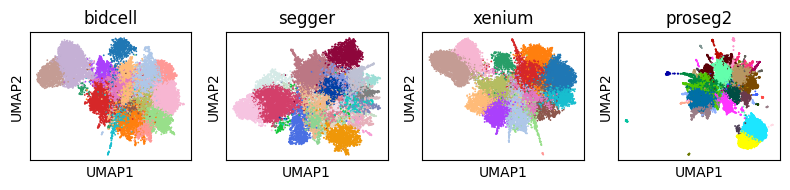

In [5]:
fig, axs = plt.subplots(1, 4, figsize=(8, 2))

# Flatten axs in case of single row/column
axs = axs.flatten()

for i, (method, st) in enumerate(st_dict.items()):
    # here, we do not want to alter the original data, so we create a deep copy
    sdata = st.sdata
    adata = sd.deepcopy(sdata.tables["table"])

    # this is all done internally by SegTraQ as well before computing the cs metrics,
    # so you are not required to run this manually
    # normalizing and log-transforming the counts
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)
    # computing a PCA and neighbors
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)

    adata = filter_zero_count_cells(adata)

    sc.tl.umap(adata)
    sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

    sc.pl.umap(
        adata,
        color="leiden",
        ax=axs[i],
        show=False,
        title=method,
        legend_loc=None,
    )

plt.tight_layout()
plt.show()

## Cluster Connectedness

The cluster connectedness (CC) is a measure that looks at the compactness of clusters.
To compute it, we use the neighborhood graph we computed with scanpy earlier.
The connectedness then iterates over all cells and computes the number of neighbors with the
same cluster assignment and divides it by the number of total neighbors.

By default, we compute this metric for Leiden clustering at resolution 0.2.
You can adjust this with the `resolution` parameter.

In [6]:
ccs = {}
for method, st in st_dict.items():
    ccs[method] = st.cs.cluster_connectedness(use_weights=True, leiden_kwargs={"flavor": "igraph"})
ccs

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:339: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(tmp, target_sum=target_sum)


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:339: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(tmp, target_sum=target_sum)


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:339: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(tmp, target_sum=target_sum)


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:339: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(tmp, target_sum=target_sum)


{'bidcell': 0.8559109403453248,
 'segger': 0.8480683994811192,
 'xenium': 0.8532126183915808,
 'proseg2': 0.9184322233371705}

## Silhouette Score

A slightly more elaborate metric is the silhouette score.
It measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation).
Values range from −1 to +1, where a high value indicates that the object is well matched to its
own cluster and poorly matched to neighboring clusters.

By default, we compute this metric for Leiden clustering at resolution 0.2.
You can adjust this with the `resolution` parameter.

In [7]:
silhouette_scores = {}
for method, st in st_dict.items():
    silhouette_scores[method] = st.cs.silhouette_score(leiden_kwargs={"flavor": "igraph"})
silhouette_scores

{'bidcell': -0.03909246250987053,
 'segger': -0.022603241726756096,
 'xenium': -0.04288879409432411,
 'proseg2': -0.009192694909870625}

## Purity

Another way to assess cluster stability is to cluster only on a subset of all cells.
For example, if we randomly select 63% ($1 - e^{-1}$) of cells and then perform Leiden
clustering on those, will our cells typically get assigned to the same cluster or to different ones?

One way to assess this is by comparing the purity between two clusterings.
For every cluster in clustering 1, we check how many other clusters it contains in clustering 2.

A purity value of 1 means that the clusters are completely pure,
whereas a value closer to 0 means that they are more mixed.

We randomly select 63% of cells, perform clustering on them, and do this five times,
to obtain five different clusterings. Then we compare them using the purity score.

**Note:** this method will recompute the PCA based on a subset of features.
If you will be using the PCA in the anndata later, you should recompute it on the whole data.

In [8]:
purities = {}
for method, st in st_dict.items():
    purities[method] = st.cs.purity(leiden_kwargs={"flavor": "igraph"})
purities

{'bidcell': 0.7608360021904563,
 'segger': 0.7680787868650978,
 'xenium': 0.7706210831559697,
 'proseg2': 0.7968477473271355}

## Adjusted Rand Index (ARI)

The adjusted rand index (ARI) is another metric to determine the similarity of
different clusterings (again, we create five clusterings based on random subsets of 63% of cells each).
Just like the purity, its values range from 0 (no similarity, not a robust clustering) to 1
(exactly the same clusters, high robustness).

In [9]:
aris = {}
for method, st in st_dict.items():
    aris[method] = st.cs.adjusted_rand_index(leiden_kwargs={"flavor": "igraph"})
aris

{'bidcell': 0.6095132723594076,
 'segger': 0.6322723778410019,
 'xenium': 0.6371819876775503,
 'proseg2': 0.6671121926793079}

At the end, all of our metrics are stored in the `spatialdata` object.

In [10]:
st_dict["proseg2"].sdata.tables["table"]

AnnData object with n_obs × n_vars = 17885 × 5095
    obs: 'cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'volume', 'label_id', 'region', 'cell_area', 'leiden_subset_cells16364_res0.6_seed42', 'leiden_subset_cells16364_res0.8_seed42', 'leiden_subset_cells16364_res1.0_seed42', 'leiden_subset_cells10309_res1.0_seed0', 'leiden_subset_cells10309_res1.0_seed1', 'leiden_subset_cells10309_res1.0_seed2', 'leiden_subset_cells10309_res1.0_seed3', 'leiden_subset_cells10309_res1.0_seed4'
    uns: 'spatialdata_attrs', 'neighbors_segtraq', 'cluster_connectedness', 'silhouette_score', 'mean_purity', 'mean_ari'
    obsm: 'X_pca_segtraq'
    layers: 'X_estimated', 'norm_log_segtraq'
    obsp: 'connectivities_segtraq', 'distances_segtraq'

## Visualization

Looking at numbers is one thing, but interpretation will be a lot easier if we visualize our results.
The following couple of codeblocks demonstrate how the four methods compare.

In [11]:
# putting everything into a dataframe for easier plotting
results_df = pd.DataFrame(
    {
        "Method": list(ccs.keys()),
        "Connectedness": list(ccs.values()),
        "Silhouette Score": list(silhouette_scores.values()),
        "Purity": list(purities.values()),
        "ARI": list(aris.values()),
    }
)

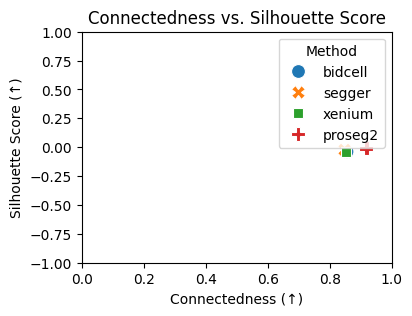

In [12]:
# plotting the connectedness vs. silhouette score
plt.figure(figsize=(4, 3))
sns.scatterplot(data=results_df, x="Connectedness", y="Silhouette Score", hue="Method", style="Method", s=100)
plt.xlabel("Connectedness (↑)")
plt.ylabel("Silhouette Score (↑)")
plt.title("Connectedness vs. Silhouette Score")
plt.xlim(0, 1)
plt.ylim(-1, 1)
plt.legend(title="Method")
plt.show()

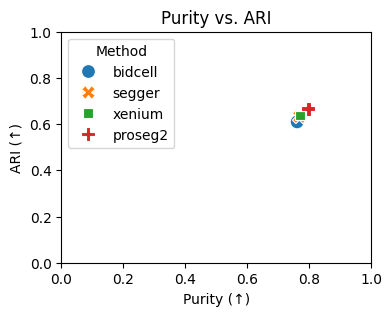

In [13]:
# plotting the purity vs. ARI
plt.figure(figsize=(4, 3))
sns.scatterplot(data=results_df, x="Purity", y="ARI", hue="Method", style="Method", s=100)
plt.xlabel("Purity (↑)")
plt.ylabel("ARI (↑)")
plt.title("Purity vs. ARI")
plt.legend(title="Method")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

## Supervised cluster stability

If you already have labels for your cells, e. g. from performing label transfer on your data,
you might want to check how compact those clusters are.
Here, we assess Cluster Connectedness and Silhouette score on clusters obtained via label transfer.
We do this by simply specifying a `label_key` in the respective functions.

In [14]:
# Running label transfer from an scRNA-seq dataset
scRNAseq_data_path = Path("../../data/xenium_5K_data/BC_scRNAseq_Janesick.h5ad")
adata_ref = ad.read_h5ad(scRNAseq_data_path)
st = segtraq.SegTraQ(
    sd.read_zarr("../../data/xenium_5K_data/proseg2.zarr"),
    images_key=None,
    tables_area_key=None,
    points_background_id=0,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)
st.run_label_transfer(adata_ref, ref_cell_type="celltype_major", ref_raw_counts_layer="raw")
sc.pp.pca(st.sdata.tables["table"])
sc.pp.neighbors(st.sdata.tables["table"])

no parent found for <ome_zarr.reader.Label object at 0x7ffde4c85710>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffdd4308ad0>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe426e0050>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffdd46fa5d0>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffdd46fabd0>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffdd4786360>: None


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:162: UserWarning: Missing 4 cell IDs in shapes: [np.int64(11273), np.int64(10307), np.int64(10308), np.int64(6870)]... These cells are present in tables, but not in shapes. This might lead to inconsistencies in the spatialdata object.
  validate_spatialdata(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:162: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes.
  validate_spatialdata(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:1769: UserWarning: Duplicate IDs detected in index 'cell_id' for shapes 'nucleus_boundaries'. Resetting and renaming index to `segtraq_id` to ensure uniqueness.
  nucleus_shapes = _ensure_index(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:190: UserWarning: Filtering control and low-quality transcrip

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:339: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(tmp, target_sum=target_sum)


In [15]:
st.cs.cluster_connectedness(cell_type_key="transferred_cell_type")

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:339: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(tmp, target_sum=target_sum)


0.7293014107420828

In [16]:
st.cs.silhouette_score(cell_type_key="transferred_cell_type")

-0.007167918607592583

## Session Info

In [17]:
print(importlib.metadata.version("spatialdata"))
print(importlib.metadata.version("spatialdata_plot"))
print(importlib.metadata.version("scanpy"))

0.8.0
0.4.0
1.12.3
